# Agente de Flip-7 com Aprendizado por Reforço
## MATA64 - Inteligência Artificial | UFBA/IC

**Tema:** Um agente aprende quando puxar uma nova carta ou parar para competir contra o melhor jogador de Flip-7.

Nesse projeto será desenvolvido 4 Políticas diferentes e comparadas entre si:

* Random ( Aleatório )
* Conservador
* Agressivo
* Q-Learning

## 1. Modelagem como MDP

### Estado (S)

O estado irá ser modelado com análises discretas para variáveis estruturais da partida e para a diferença de pontuação:

1. Diferença de pontuação      ( `ScoreDifferenceCategory.DESTROYED` | `ScoreDifferenceCategory.LOSING` | `ScoreDifferenceCategory.TIED` | `ScoreDifferenceCategory.WINNING` | `ScoreDifferenceCategory.CRUSHING` )
2. Quantidade de cartas do agente     ( `CardCountCategory.START` | `CardCountCategory.MIDDLE` | `CardCountCategory.NEAR_FLIP7` )
3. Risco de repetir uma carta         ( baixo | medio | alto | critico )
4. Quantidade de cartas do adversário ( `CardCountCategory.START` | `CardCountCategory.MIDDLE` | `CardCountCategory.NEAR_FLIP7` )


### Ações (A)

Cada estado terá 2 ações possíveis:

* `0` - Puxar carta
* `1` - Parar

In [1]:
from enum import IntEnum


class Action(IntEnum):
    DRAW_CARD = 0
    STOP = 1


ACTIONS = tuple(Action)

#### Observação sobre a Ação 0 ( Puxar carta )

> o agente remove uma carta aleatória do monte. Se a numeração da carta já existir no conjunto de cartas do agente, ele perde tudo e encerra a partida com 0 pontos.

#### Observação sobre a Ação 1 ( Parar )

> o agente encerra sua participação na rodada e mantém a pontuação formada pelas cartas puxadas. Se o adversário ainda estiver ativo, ele continuará puxando

### Transições (T)

Abaixo segue a tabela, modelando as transições principais da partida:

| Evento | Quando ocorre | Descrição |
|--------|---------------|-----------|
| Carta segura | Carta nova para o agente | Carta entra na mão do agente e soma pontos |
| Estouro | Carta repetida para o agente | Agente perde tudo e termina com 0 pontos |
| Parada voluntária | Agente escolhe parar | Agente mantém a pontuação atual |
| Flip-7 | Agente alcança 7 cartas sem repetir | Agente ganha 15 pontos extras e encerra a rodada |
| Parada do adversário | Adversário tenta puxar carta repetida | A carta volta ao monte e o adversário para sem perder pontos |

In [2]:
from enum import Enum


class RoundEvent(Enum):
    SAFE_DRAW = "safe_draw"
    BUST = "bust"
    STOP = "stop"
    FLIP7 = "flip7"
    OPPONENT_SPECIAL_STOP = "opponent_special_stop"

### Recompensa (R)

Nessa instância de problema, a recompensa terá dois componentes: um feedback a cada passo e um ajuste terminal quando a rodada termina.

#### Recompensa por cada passo

Durante a rodada, cada `step()` recebe o delta da diferença de pontuação entre agente e adversário:

$$R_{passo} = (score_{agente}^{novo} - score_{adversario}^{novo}) - (score_{agente}^{anterior} - score_{adversario}^{anterior})$$

Esse valor indica se a ação melhorou ou piorou a posição relativa do agente no placar. Se o agente aumenta sua vantagem, a recompensa do passo é positiva; se o adversário melhora a diferença ou o agente perde pontos, a recompensa do passo é negativa.

#### Recompensa no estado final

Quando a partida termina, é somada uma recompensa terminal baseada no resultado e na margem final:

$$R_{final} = K_{REWARD} + K_{BONUS\_TO\_REVENGE} \cdot \tanh(DELTA / LIMIT_{TO\_REVENGE})$$

onde:

| Termo | Valor | Descrição e impacto |
|-------|-------|---------------------|
| `DELTA` | pontuação_final_agente - pontuação_final_adversário | Mede o saldo final da partida. Valores positivos indicam vitória do agente; negativos indicam derrota; zero indica empate. Quanto maior o módulo, maior a influência da margem na recompensa final. |
| `K_REWARD` | `100` para vitória, `-100` para derrota e `0` para empate | Define o peso principal do resultado. Faz o agente priorizar ganhar a partida, e não apenas melhorar pequenos saldos intermediários. |
| `K_BONUS_TO_REVENGE` | `50` | Controla o bônus ou penalidade adicional pela margem final. Aumenta a recompensa quando o agente vence por mais pontos e aumenta a punição quando perde por mais pontos. |
| `LIMIT_TO_REVENGE` | `50` | Define qual diferença de pontos já é considerada grande. Diferenças próximas ou maiores que esse valor fazem a `tanh` se aproximar do limite máximo do bônus. |

A função `tanh` transforma a margem `DELTA / LIMIT_TO_REVENGE` para um valor entre `-1` e `1`. Isso evita que uma diferença muito grande gere recompensa sem limite: quando o agente vence por margem alta, o bônus se aproxima de `+K_BONUS_TO_REVENGE`; quando perde por margem alta, se aproxima de `-K_BONUS_TO_REVENGE`; em empates ou margens pequenas, o impacto fica próximo de zero.



# Configurando o Seeding

Para manter os resultados previsíveis durante cada execução desse modelo, iremos configurar o Seeding para *42*.

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from dataclasses import dataclass, field

np.random.seed(42)
random.seed(42)

## 2. Representação do Estado

Para simplificar o nosso cenário, iremos utilizar funções auxiliares que convertam apenas variáveis estruturais para valores qualitativos e subjetivos.

> Nesse cenário, o risco de repetir carta é calculado a partir do monte restante e das cartas que o agente já possui. Como todos os jogadores visualizam as cartas puxadas, esse risco é uma informação disponível para a tomada de decisão.

In [4]:
class RiskCategory(Enum):
    LOW = "baixo"
    MEDIUM = "medio"
    HIGH = "alto"
    CRITICAL = "critico"


class CardCountCategory(Enum):
    START = "inicio"
    MIDDLE = "meio"
    NEAR_FLIP7 = "perto_flip7"


class ScoreDifferenceCategory(Enum):
    DESTROYED = "destruido"
    LOSING = "perdendo"
    TIED = "empatado"
    WINNING = "ganhando"
    CRUSHING = "amassando"


In [5]:
def score_difference(env) -> int:
    return env.agent.raw_score - env.opponent.raw_score


def discretize_score_difference(score_diff: int) -> ScoreDifferenceCategory:
    if score_diff <= -20:  return ScoreDifferenceCategory.DESTROYED
    if score_diff < 0:  return ScoreDifferenceCategory.LOSING
    if score_diff == 0:  return ScoreDifferenceCategory.TIED
    if score_diff < 20:  return ScoreDifferenceCategory.WINNING
    return ScoreDifferenceCategory.CRUSHING


def discretize_cards(n_cards: int) -> CardCountCategory:
    if n_cards <= 2:  return CardCountCategory.START
    if n_cards <= 4:  return CardCountCategory.MIDDLE
    return CardCountCategory.NEAR_FLIP7


def discretize_risk(risk: float) -> RiskCategory:
    if risk < 0.10:  return RiskCategory.LOW
    if risk < 0.25:  return RiskCategory.MEDIUM
    if risk < 0.40:  return RiskCategory.HIGH
    return RiskCategory.CRITICAL


def duplicate_risk(cards: list[int], deck: list[int]) -> float:
    if not cards or not deck:
        return 0.0

    repeated_values = set(cards)
    risky_cards = sum(1 for card in deck if card in repeated_values)
    return risky_cards / len(deck)


def get_state(env) -> tuple:
    return (
        discretize_score_difference(score_difference(env)),
        discretize_cards(len(env.agent.cards)),
        discretize_risk(duplicate_risk(env.agent.cards, env.deck)),
        discretize_cards(len(env.opponent.cards)),
    )

## 3. Probabilidades do Monte

As probabilidades desse problema não serão definidas manualmente. Elas surgem da própria composição do baralho.

No monte existem cartas numeradas de `0` a `12`. A quantidade de cartas de cada número corresponde ao seu valor, exceto a carta `0`, que aparece apenas uma vez.

| Carta | Quantidade |
|-------|------------|
| 0 | 1 |
| 1 | 1 |
| 2 | 2 |
| ... | ... |
| 12 | 12 |

Portanto, a chance de estourar muda conforme as cartas saem do monte e conforme as cartas que o agente já possui.

In [6]:
CARD_COUNTS = {0: 1, **{number: number for number in range(1, 13)}}
FLIP7_CARD_COUNT = 7
FLIP7_BONUS = 15
K_REWARD = {
    "win": 100,
    "loss": -100,
    "draw": 0,
}
K_BONUS_TO_REVENGE = 50
LIMIT_TO_REVENGE = 50


def build_deck() -> list[int]:
    deck = []
    for card, amount in CARD_COUNTS.items():
        deck.extend([card] * amount)
    random.shuffle(deck)
    return deck


def draw_random_card(deck: list[int]) -> int:
    card_index = random.randrange(len(deck))
    return deck.pop(card_index)


DECK_SIZE = sum(CARD_COUNTS.values())
DECK_SIZE

79

## 4. Ambiente de Simulação

O ambiente irá simular o ciclo de decisão do MDP.

A cada `step()` o agente escolhe uma ação descrita acima. Em seguida, quando a partida ainda não terminou, o adversário faz sua jogada usando a regra especial do melhor jogador de Flip-7.

**Ação 0 - Puxar carta:**
o agente compra uma carta aleatória do monte. Se ela for nova para sua mão, a carta é adicionada e a pontuação aumenta. Se for repetida, o agente perde tudo e encerra com 0 pontos.

**Ação 1 - Parar:**
o agente para voluntariamente e preserva a pontuação atual. Se o adversário ainda estiver ativo, ele continua puxando cartas até tentar repetir uma numeração ou alcançar Flip-7.

**Adversário especial:**
o adversário sempre tenta continuar. Quando ele compraria uma carta repetida, ele devolve essa carta ao monte e para imediatamente, sem perder a pontuação acumulada.

In [7]:
@dataclass
class PlayerState:
    cards: list[int] = field(default_factory=list)
    stopped: bool = False
    busted: bool = False
    flip7_bonus: bool = False

    @property
    def raw_score(self) -> int:
        return sum(self.cards)

    @property
    def final_score(self) -> int:
        if self.busted:
            return 0
        return self.raw_score + (FLIP7_BONUS if self.flip7_bonus else 0)


def player_has_flip7(player: PlayerState) -> bool:
    return len(player.cards) >= FLIP7_CARD_COUNT and not player.busted


class Flip7Environment:
    def __init__(self):
        self.deck = None
        self.agent = None
        self.opponent = None
        self.done = False
        self.agent_won = False
        self.agent_lost = False
        self.draw_game = False
        self.agent_final_score = 0
        self.opponent_final_score = 0
        self.last_event = None

    def reset(self) -> tuple:
        self.deck = build_deck()
        self.agent = PlayerState()
        self.opponent = PlayerState()
        self.done = False
        self.agent_won = self.agent_lost = self.draw_game = False
        self.agent_final_score = self.opponent_final_score = 0
        self.last_event = None

        self._deal_initial_card(self.agent)
        self._deal_initial_card(self.opponent)
        return get_state(self)

    def step(self, action: Action) -> tuple:
        if self.done:
            raise ValueError("A partida já terminou. Chame reset() para iniciar uma nova simulação.")

        previous_diff = self._current_score_difference()

        if action == Action.STOP:
            self.agent.stopped = True
            self.last_event = RoundEvent.STOP
            self._finish_opponent_turns()
            self.done = True
            reward = self._step_reward(previous_diff) + self._terminal_reward()
            return get_state(self), reward, self.done

        self._agent_draw()

        if not self.done:
            self._opponent_turn()

        reward = self._step_reward(previous_diff)
        if self.done:
            reward += self._terminal_reward()

        return get_state(self), reward, self.done

    def _deal_initial_card(self, player: PlayerState) -> None:
        player.cards.append(draw_random_card(self.deck))

    def _agent_draw(self) -> None:
        if not self.deck:
            self.agent.stopped = True
            self.last_event = RoundEvent.STOP
            self._finish_opponent_turns()
            self.done = True
            return

        card = draw_random_card(self.deck)

        if card in self.agent.cards:
            self.agent.busted = True
            self.agent.stopped = True
            self.last_event = RoundEvent.BUST
            self._finish_opponent_turns()
            self.done = True
            return

        self.agent.cards.append(card)
        self.last_event = RoundEvent.SAFE_DRAW

        if player_has_flip7(self.agent):
            self.agent.flip7_bonus = True
            self.agent.stopped = True
            self.last_event = RoundEvent.FLIP7
            self._finish_opponent_turns()
            self.done = True

    def _opponent_turn(self) -> None:
        if self.opponent.stopped or not self.deck:
            self.opponent.stopped = True
            return

        card = draw_random_card(self.deck)

        if card in self.opponent.cards:
            self.deck.append(card)
            self.opponent.stopped = True
            self.last_event = RoundEvent.OPPONENT_SPECIAL_STOP
            return

        self.opponent.cards.append(card)

        if player_has_flip7(self.opponent):
            self.opponent.flip7_bonus = True
            self.opponent.stopped = True

    def _finish_opponent_turns(self) -> None:
        while not self.opponent.stopped and self.deck:
            self._opponent_turn()

        if not self.deck:
            self.opponent.stopped = True

    def _current_score_difference(self) -> int:
        return self.agent.final_score - self.opponent.final_score

    def _step_reward(self, previous_diff: int) -> float:
        return self._current_score_difference() - previous_diff

    def _terminal_reward(self) -> float:
        self.agent_final_score = self.agent.final_score
        self.opponent_final_score = self.opponent.final_score

        DELTA = self.agent_final_score - self.opponent_final_score
        self.agent_won = DELTA > 0
        self.agent_lost = DELTA < 0
        self.draw_game = DELTA == 0

        if self.agent_won:
            k_reward = K_REWARD["win"]
        elif self.agent_lost:
            k_reward = K_REWARD["loss"]
        else:
            k_reward = K_REWARD["draw"]

        revenge_bonus = K_BONUS_TO_REVENGE * np.tanh(DELTA / LIMIT_TO_REVENGE)
        return k_reward + revenge_bonus


## 5. Políticas Baseline

Três políticas servem de referência para comparação com o agente aprendido. Cada política é descrita antes do respectivo código para deixar explícita a regra de decisão usada em cada baseline.


### Política Random

A política **Random** escolhe uma ação aleatória entre puxar carta e parar. Ela serve como linha de base mínima para comparar se as demais estratégias conseguem usar o estado da partida de forma mais inteligente.


In [8]:
def random_policy(state) -> Action:
    return random.choice(ACTIONS)


### Política Conservador

A política **Conservador** tenta preservar vantagem quando já está na frente e evita puxar quando o risco cresce. Ela só aceita puxar quando está atrás no placar ou quando está perto de Flip-7 com risco baixo.


In [9]:
def conservative_policy(state) -> Action:
    score_diff, agent_cards, risk, opponent_cards = state

    if risk in (RiskCategory.HIGH, RiskCategory.CRITICAL):
        return Action.STOP

    if score_diff in (ScoreDifferenceCategory.WINNING, ScoreDifferenceCategory.CRUSHING):
        return Action.STOP

    if agent_cards == CardCountCategory.NEAR_FLIP7 and risk == RiskCategory.LOW:
        return Action.DRAW_CARD

    if score_diff == ScoreDifferenceCategory.DESTROYED and risk in (RiskCategory.LOW, RiskCategory.MEDIUM):
        return Action.DRAW_CARD

    if score_diff == ScoreDifferenceCategory.LOSING and risk == RiskCategory.LOW:
        return Action.DRAW_CARD

    return Action.STOP


### Política Agressivo

A política **Agressivo** aceita mais risco quando está atrás no placar ou quando ainda existe uma chance razoável de buscar o bonus de Flip-7. Ela só para imediatamente em risco crítico ou quando já tem vantagem suficiente com risco alto.


In [10]:
def aggressive_policy(state) -> Action:
    score_diff, agent_cards, risk, opponent_cards = state

    if risk == RiskCategory.CRITICAL:
        return Action.STOP

    if agent_cards == CardCountCategory.NEAR_FLIP7 and risk != RiskCategory.CRITICAL:
        return Action.DRAW_CARD

    if score_diff in (ScoreDifferenceCategory.DESTROYED, ScoreDifferenceCategory.LOSING):
        return Action.DRAW_CARD

    if score_diff in (ScoreDifferenceCategory.TIED, ScoreDifferenceCategory.WINNING) and risk in (RiskCategory.LOW, RiskCategory.MEDIUM):
        return Action.DRAW_CARD

    if score_diff == ScoreDifferenceCategory.CRUSHING and risk in (RiskCategory.HIGH, RiskCategory.CRITICAL):
        return Action.STOP

    return Action.DRAW_CARD


## 6. Q-Learning

Algoritmo de Aprendizado por Reforço baseado em diferença temporal (TD).
O agente mantém uma tabela Q(s, a), com 2 ações possíveis, e atualiza os valores a cada passo usando:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]$$

| Parâmetro | Constante | Valor | Descrição |
|-----------|-----------|-------|-----------|
| alpha | `ALPHA` | 0.1 | *Taxa de aprendizado*: controla quanto cada nova experiência afeta os valores já obtidos |
| gamma | `GAMMA` | 0.95 | *Fator de desconto*: define a importância das recompensas futuras |
| epsilon_0 | `EPSILON_START` | 0.35 | *Exploração inicial*: probabilidade inicial de escolher uma ação aleatória |
| epsilon_min | `EPSILON_END` | 0.02 | *Exploração mínima*: menor probabilidade de escolher uma ação aleatória durante o treinamento |
| N | `EPISODES` | 50_000 | *Quantidade de episódios*: número de simulações utilizadas para treinar o agente |

O agente aprende quando vale a pena continuar buscando pontos e quando é melhor parar para preservar sua pontuação contra o adversário especial.

In [11]:
ALPHA = 0.1
GAMMA = 0.95
EPSILON_START = 0.35
EPSILON_END = 0.02
EPISODES = 50_000


def move_epsilon(*, start: float, end: float, current: int, total: int) -> float:
    return max(
        end,
        # Aqui iremos mover gradualmente o epsilon de start -> end a medida que o treinamento chegue ao final
        start - current * (start - end) / total,
    )


def is_random_action(epsilon: float) -> bool:
    return random.random() < epsilon


def get_best_action_for(state, Q) -> Action:
    return Action(np.argmax(Q[state]))


def get_best_q_value_for(state, Q) -> float:
    return np.max(Q[state])


def train_q_learning(episodes=EPISODES, alpha=ALPHA, gamma=GAMMA,
                     epsilon_start=EPSILON_START, epsilon_end=EPSILON_END):

    # Primeiro, criaremos um dicionário [State, Q-Values] onde Q-Values é um Vetor de Cardinalidade |Ações|
    Q = defaultdict(lambda: np.zeros(len(Action)))

    # Vamos armazenar o histórico de recompensas e do saldo final por episódio
    rewards_log = []
    final_score_diffs_log = []

    # Iniciando a Execução de cada Episódio
    for ep in range(episodes):
        epsilon = move_epsilon(
            start=epsilon_start,
            end=epsilon_end,
            current=ep,
            total=episodes,
        )
        env = Flip7Environment()
        state = env.reset()
        total_reward, done = 0, False

        while not done:
            # Vamos decidir qual é a melhor Ação ( Exploit ) ou se vamos Explorar
            action = get_best_action_for(state, Q) if not is_random_action(epsilon) else random.choice(ACTIONS)

            # Aplicamos a Ação escolhida, extraindo o estado resultante, a recompensa obtida e se foi finalizado
            next_state, reward, done = env.step(action)

            # Vamos melhorar nossa Tabela Q, aplicando a fórmula:
            # Q(s, a) <- Q(s, a) + alpha * [r + gamma * max Q(s', a') - Q(s, a)]
            # Q(s, a): valor atual da ação a no estado s
            # r: recompensa recebida;
            # alpha: taxa de aprendizado
            # gamma: desconto das recompensas futuras
            # max Q(s', a'): melhor valor possível no próximo estado s'

            Q[state][action] = Q[state][action] + alpha * (
                reward + gamma * get_best_q_value_for(next_state, Q) - Q[state][action]
            )

            state = next_state
            total_reward += reward

        # Adicione a recompensa e o saldo final desse episódio
        rewards_log.append(total_reward)
        final_score_diffs_log.append(env.agent_final_score - env.opponent_final_score)

    return Q, rewards_log, final_score_diffs_log


Q, rewards_log, final_score_diffs_log = train_q_learning()


### Política Treinada pelo Q-Learning

Após o treinamento, extraímos uma nova política a partir da tabela Q aprendida. Para cada estado, essa política seleciona a ação que possui o maior valor Q estimado.

In [12]:
def q_policy(state) -> Action:
    return get_best_action_for(state, Q)

## 7. Experimentos

Cada política é avaliada em **2000 simulações independentes**.

Métricas coletadas por simulação:
- Recompensa total acumulada
- Pontuação final do agente
- Pontuação final do adversário
- Taxa de vitória
- Taxa de derrota
- Taxa de empate
- Taxa de estouro do agente
- Taxa de Flip-7 do agente
- Quantidade média de cartas mantidas no fim da rodada
- Média do DELTA final nas derrotas

In [13]:
def run_simulation(policy_fn, n=2000):
    metrics = {
        "rewards": [],
        "agent_score": [],
        "opponent_score": [],
        "final_score_diff": [],
        "won": [],
        "lost": [],
        "draw_game": [],
        "agent_busted": [],
        "agent_flip7": [],
        "opponent_flip7": [],
        "agent_cards": [],
        "opponent_cards": [],
        "actions_draw": [],
        "actions_stop": [],
    }

    for _ in range(n):
        env = Flip7Environment()
        state, done, total = env.reset(), False, 0
        draws = stops = 0

        while not done:
            action = policy_fn(state)
            draws += int(action == Action.DRAW_CARD)
            stops += int(action == Action.STOP)
            state, reward, done = env.step(action)
            total += reward

        metrics["rewards"].append(total)
        metrics["agent_score"].append(env.agent_final_score)
        metrics["opponent_score"].append(env.opponent_final_score)
        metrics["final_score_diff"].append(env.agent_final_score - env.opponent_final_score)
        metrics["won"].append(int(env.agent_won))
        metrics["lost"].append(int(env.agent_lost))
        metrics["draw_game"].append(int(env.draw_game))
        metrics["agent_busted"].append(int(env.agent.busted))
        metrics["agent_flip7"].append(int(env.agent.flip7_bonus))
        metrics["opponent_flip7"].append(int(env.opponent.flip7_bonus))
        metrics["agent_cards"].append(len(env.agent.cards))
        metrics["opponent_cards"].append(len(env.opponent.cards))
        metrics["actions_draw"].append(draws)
        metrics["actions_stop"].append(stops)

    return metrics


results = {
    "Random":       run_simulation(random_policy),
    "Conservador":  run_simulation(conservative_policy),
    "Agressivo":    run_simulation(aggressive_policy),
    "Q-Learning":   run_simulation(q_policy),
}

## 8. Resultados e Análise

In [14]:
def summarize_results(results):
    summary = []
    for policy_name, metrics in results.items():
        summary.append({
            "politica": policy_name,
            "recompensa_media": np.mean(metrics["rewards"]),
            "pontuacao_agente": np.mean(metrics["agent_score"]),
            "pontuacao_adversario": np.mean(metrics["opponent_score"]),
            "saldo_final": np.mean(metrics["final_score_diff"]),
            "vitorias": np.mean(metrics["won"]),
            "derrotas": np.mean(metrics["lost"]),
            "empates": np.mean(metrics["draw_game"]),
            "estouros": np.mean(metrics["agent_busted"]),
            "flip7_agente": np.mean(metrics["agent_flip7"]),
            "cartas_agente": np.mean(metrics["agent_cards"]),
        })
    return summary


summary = summarize_results(results)

for row in summary:
    print(
        f"{row['politica']:12s} | "
        f"recompensa={row['recompensa_media']:7.2f} | "
        f"pontos_agente={row['pontuacao_agente']:5.2f} | "
        f"pontos_adv={row['pontuacao_adversario']:5.2f} | "
        f"saldo={row['saldo_final']:6.2f} | "
        f"vitórias={row['vitorias']:.3f} | "
        f"estouros={row['estouros']:.3f} | "
        f"flip7={row['flip7_agente']:.3f}"
    )

Random       | recompensa=-112.97 | pontos_agente=11.78 | pontos_adv=31.54 | saldo=-19.77 | vitórias=0.114 | estouros=0.130 | flip7=0.001
Conservador  | recompensa=-122.26 | pontos_agente=11.31 | pontos_adv=31.80 | saldo=-20.48 | vitórias=0.071 | estouros=0.025 | flip7=0.000
Agressivo    | recompensa= -78.10 | pontos_agente=14.31 | pontos_adv=31.60 | saldo=-17.29 | vitórias=0.262 | estouros=0.622 | flip7=0.007
Q-Learning   | recompensa= -48.55 | pontos_agente=17.11 | pontos_adv=31.73 | saldo=-14.62 | vitórias=0.384 | estouros=0.415 | flip7=0.013


### Mapa da Política Aprendida

Cada célula da tabela representa a ação mais frequente recomendada pelo Q-Learning entre estados visitados durante o treinamento.

O estado completo possui quatro dimensões discretizadas: diferença de pontuação, cartas do agente, risco de repetição e cartas do adversário. A tabela mostra diretamente as categorias qualitativas usadas pelo treinamento.

In [15]:
from IPython.display import HTML, display


CARD_COUNT_CATEGORIES = [
    CardCountCategory.START,
    CardCountCategory.MIDDLE,
    CardCountCategory.NEAR_FLIP7,
]
RISK_CATEGORIES = [
    RiskCategory.LOW,
    RiskCategory.MEDIUM,
    RiskCategory.HIGH,
    RiskCategory.CRITICAL,
]
SCORE_DIFF_CATEGORIES = [
    ScoreDifferenceCategory.DESTROYED,
    ScoreDifferenceCategory.LOSING,
    ScoreDifferenceCategory.TIED,
    ScoreDifferenceCategory.WINNING,
    ScoreDifferenceCategory.CRUSHING,
]

ACTION_COLORS = {
    Action.DRAW_CARD: "seagreen",
    Action.STOP: "tomato",
}
ACTION_LABELS = {
    Action.DRAW_CARD: "Puxar",
    Action.STOP: "Parar",
}

card_states = [(agent_cards, opponent_cards) for agent_cards in CARD_COUNT_CATEGORIES for opponent_cards in CARD_COUNT_CATEGORIES]


def aggregate_best_action(*, score_diff, agent_cards, opponent_cards, risk):
    actions = []
    for state in Q:
        state_score_diff, state_agent_cards, state_risk, state_opponent_cards = state
        if (
            state_score_diff == score_diff
            and state_agent_cards == agent_cards
            and state_opponent_cards == opponent_cards
            and state_risk == risk
        ):
            actions.append(get_best_action_for(state, Q))

    if not actions:
        return None, 0

    action_counts = Counter(actions)
    return action_counts.most_common(1)[0][0], len(actions)


def policy_table_html(*, risk: RiskCategory) -> str:
    header = "".join(f"<th>{score_diff.value}</th>" for score_diff in SCORE_DIFF_CATEGORIES)
    rows = []

    for agent_cards, opponent_cards in card_states:
        cells = []
        for score_diff in SCORE_DIFF_CATEGORIES:
            action, visits = aggregate_best_action(
                score_diff=score_diff,
                agent_cards=agent_cards,
                opponent_cards=opponent_cards,
                risk=risk,
            )
            if action is None:
                cells.append('<td class="not-visited">Não visitado</td>')
            else:
                cells.append(
                    f'<td style="background:{ACTION_COLORS[action]}">{ACTION_LABELS[action]}<br><small>{visits} estados</small></td>'
                )

        rows.append(
            f"<tr><th>Agente: {agent_cards.value}<br><small>Adv: {opponent_cards.value}</small></th>{''.join(cells)}</tr>"
        )

    return f"""
    <h4>Risco de repetição: {risk.value}</h4>
    <div class="policy-table-container">
        <table class="policy-table">
            <thead><tr><th>Cartas / Diferença</th>{header}</tr></thead>
            <tbody>{''.join(rows)}</tbody>
        </table>
    </div>
    """


legend = "".join(
    f'<span style="background:{ACTION_COLORS[action]}; padding:6px 10px; margin-right:8px; border:1px solid #777">{ACTION_LABELS[action]}</span>'
    for action in Action
)

styles = """
<style>
.policy-table-container { overflow-x: auto; margin-bottom: 24px; }
.policy-table { border-collapse: collapse; font-size: 12px; text-align: center; }
.policy-table th, .policy-table td { border: 1px solid #777; min-width: 92px; padding: 8px; }
.policy-table th { background: #f2f2f2; font-weight: bold; }
.policy-table .not-visited { background: white; color: #999; }
</style>
"""

display(HTML(styles + f"<div style='margin-bottom:18px'>{legend}</div>" + "".join(policy_table_html(risk=risk) for risk in RISK_CATEGORIES)))

Cartas / Diferença,destruido,perdendo,empatado,ganhando,amassando
Agente: inicioAdv: inicio,Puxar1 estados,Puxar1 estados,Puxar1 estados,Puxar1 estados,Não visitado
Agente: inicioAdv: meio,Puxar1 estados,Puxar1 estados,Não visitado,Não visitado,Não visitado
Agente: inicioAdv: perto_flip7,Puxar1 estados,Puxar1 estados,Não visitado,Não visitado,Não visitado
Agente: meioAdv: inicio,Não visitado,Puxar1 estados,Puxar1 estados,Puxar1 estados,Não visitado
Agente: meioAdv: meio,Puxar1 estados,Puxar1 estados,Não visitado,Não visitado,Não visitado
Agente: meioAdv: perto_flip7,Puxar1 estados,Não visitado,Não visitado,Não visitado,Não visitado
Agente: perto_flip7Adv: inicio,Não visitado,Não visitado,Não visitado,Não visitado,Não visitado
Agente: perto_flip7Adv: meio,Não visitado,Não visitado,Não visitado,Não visitado,Não visitado
Agente: perto_flip7Adv: perto_flip7,Não visitado,Não visitado,Não visitado,Não visitado,Não visitado
Cartas / Diferença,destruido,perdendo,empatado,ganhando,amassando


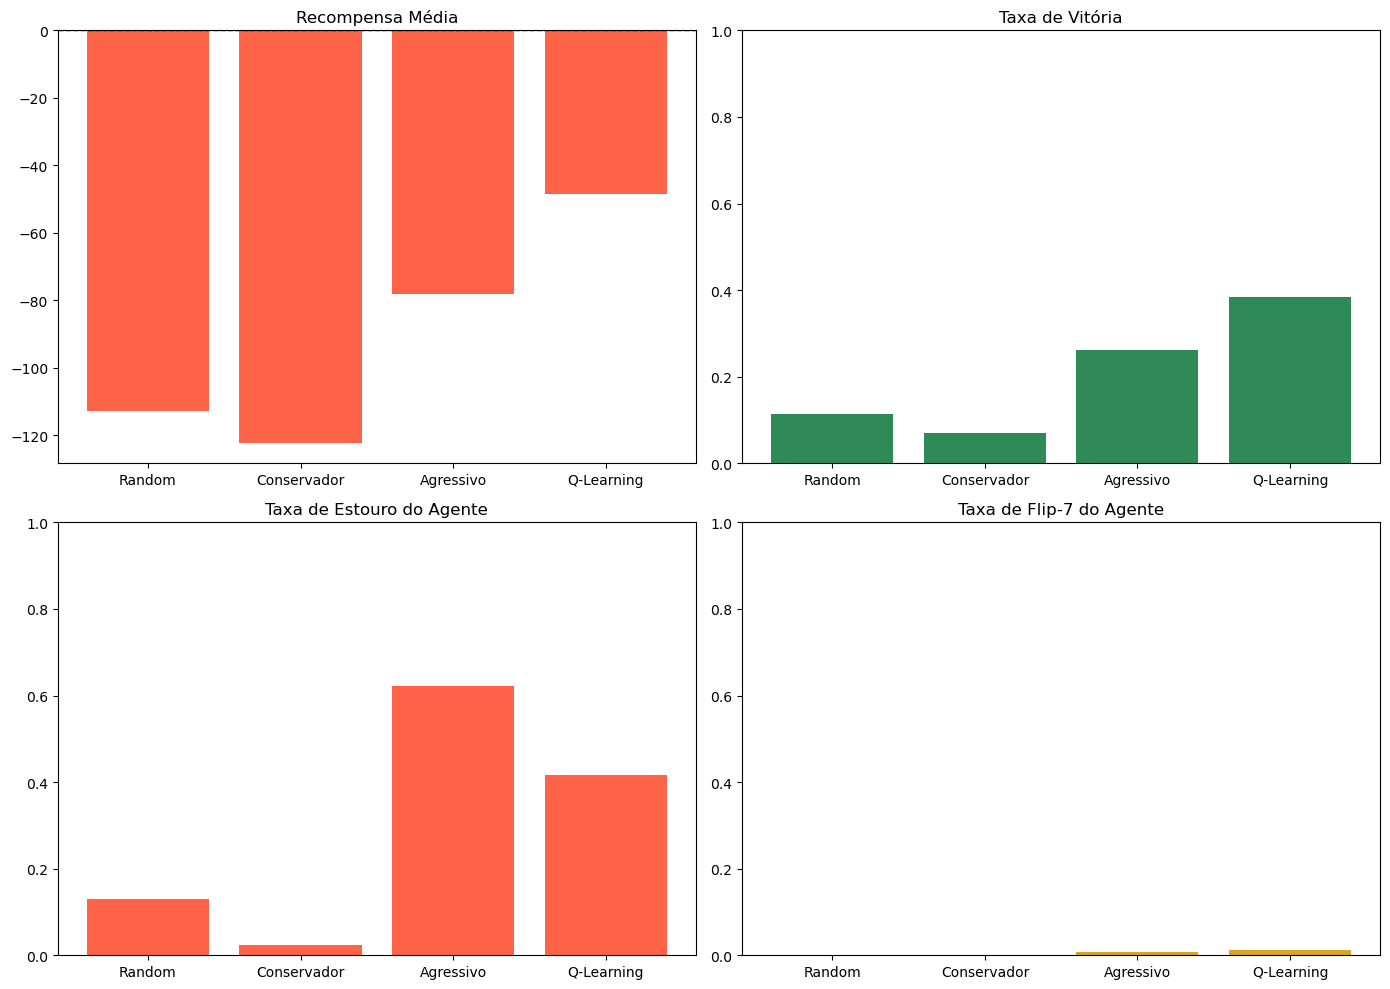

In [16]:
labels = list(results.keys())
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

average_rewards = [np.mean(r["rewards"]) for r in results.values()]
reward_colors = ["tomato" if reward < 0 else "steelblue" for reward in average_rewards]

axes[0, 0].bar(labels, average_rewards, color=reward_colors)
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0, 0].set_title("Recompensa Média")

axes[0, 1].bar(labels, [np.mean(r["won"]) for r in results.values()], color="seagreen")
axes[0, 1].set_title("Taxa de Vitória")
axes[0, 1].set_ylim(0, 1)

axes[1, 0].bar(labels, [np.mean(r["agent_busted"]) for r in results.values()], color="tomato")
axes[1, 0].set_title("Taxa de Estouro do Agente")
axes[1, 0].set_ylim(0, 1)

axes[1, 1].bar(labels, [np.mean(r["agent_flip7"]) for r in results.values()], color="goldenrod")
axes[1, 1].set_title("Taxa de Flip-7 do Agente")
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("flip7_resultados_politicas.png", dpi=150)
plt.show()

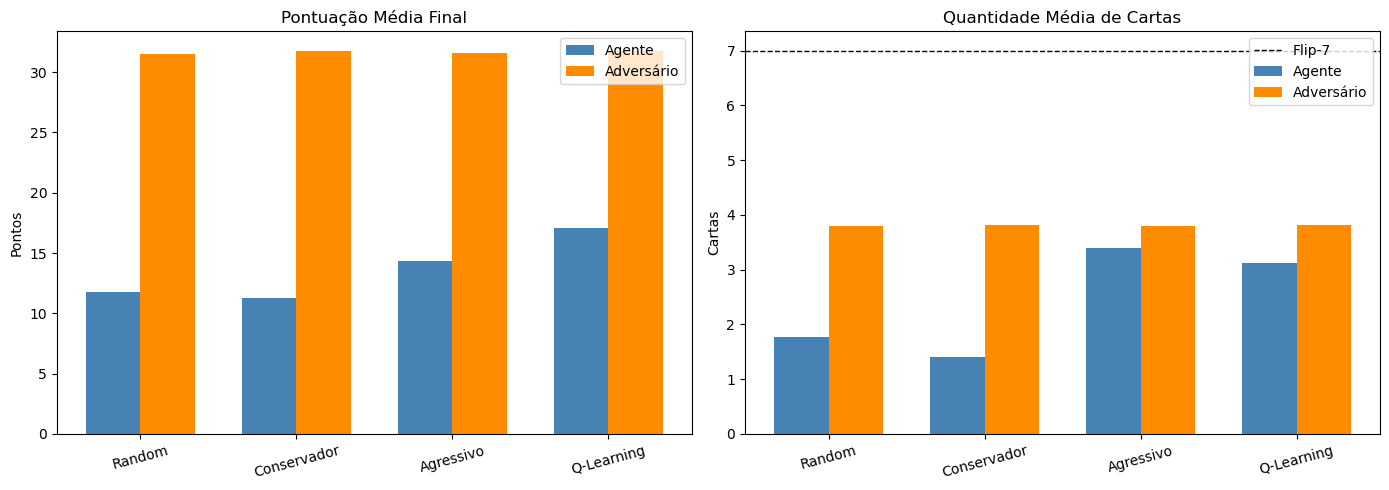

In [17]:
x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

agent_scores = [np.mean(r["agent_score"]) for r in results.values()]
opponent_scores = [np.mean(r["opponent_score"]) for r in results.values()]
axes[0].bar(x - width / 2, agent_scores, width, label="Agente", color="steelblue")
axes[0].bar(x + width / 2, opponent_scores, width, label="Adversário", color="darkorange")
axes[0].set_title("Pontuação Média Final")
axes[0].set_ylabel("Pontos")
axes[0].set_xticks(x, labels, rotation=15)
axes[0].legend()

agent_cards = [np.mean(r["agent_cards"]) for r in results.values()]
opponent_cards = [np.mean(r["opponent_cards"]) for r in results.values()]
axes[1].bar(x - width / 2, agent_cards, width, label="Agente", color="steelblue")
axes[1].bar(x + width / 2, opponent_cards, width, label="Adversário", color="darkorange")
axes[1].axhline(FLIP7_CARD_COUNT, color="black", linestyle="--", linewidth=1, label="Flip-7")
axes[1].set_title("Quantidade Média de Cartas")
axes[1].set_ylabel("Cartas")
axes[1].set_xticks(x, labels, rotation=15)
axes[1].legend()

plt.tight_layout()
plt.savefig("flip7_placar_cartas.png", dpi=150)
plt.show()

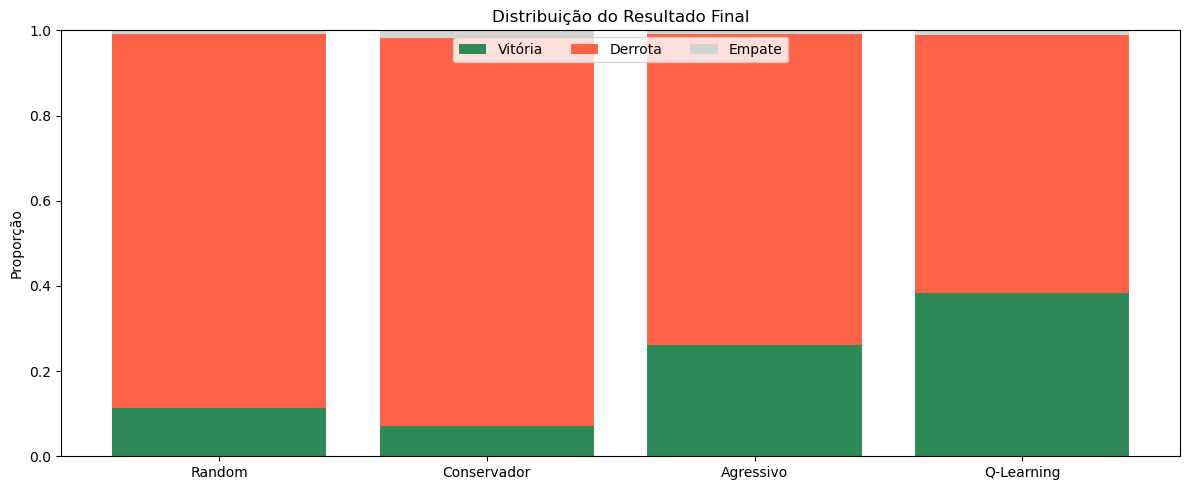

In [18]:
outcome_keys = ["won", "lost", "draw_game"]
outcome_labels = ["Vitória", "Derrota", "Empate"]
outcome_colors = ["seagreen", "tomato", "lightgray"]

fig, axis = plt.subplots(figsize=(12, 5))
bottoms = np.zeros(len(labels))

for key, label, color in zip(outcome_keys, outcome_labels, outcome_colors):
    values = [np.mean(results[policy][key]) for policy in labels]
    axis.bar(labels, values, bottom=bottoms, label=label, color=color)
    bottoms += values

axis.set_ylim(0, 1)
axis.set_ylabel("Proporção")
axis.set_title("Distribuição do Resultado Final")
axis.legend(loc="upper center", ncol=3)

plt.tight_layout()
plt.savefig("flip7_resultado_final.png", dpi=150)
plt.show()

### Severidade das Derrotas

Este gráfico foca apenas nas simulações em que cada política perdeu. Para essas partidas, calculamos a média do `DELTA` final (`pontuação_final_agente - pontuação_final_adversário`). Quanto mais negativo o valor, maior foi a distância média das derrotas.


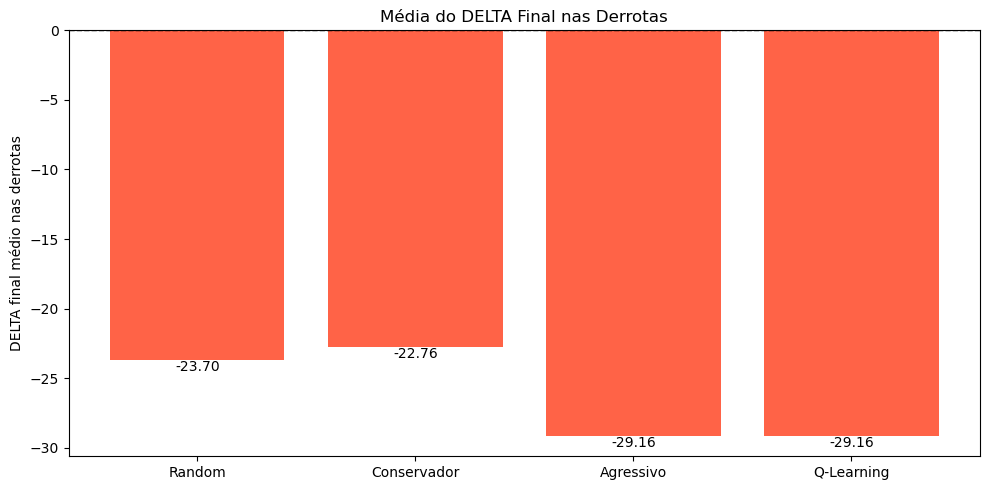

In [19]:
def mean_final_delta_on_losses(metrics):
    loss_deltas = [
        delta
        for delta, lost in zip(metrics["final_score_diff"], metrics["lost"])
        if lost
    ]
    return np.mean(loss_deltas) if loss_deltas else 0


loss_delta_means = [mean_final_delta_on_losses(results[policy]) for policy in labels]

fig, axis = plt.subplots(figsize=(10, 5))
bars = axis.bar(labels, loss_delta_means, color="tomato")
axis.axhline(0, color="black", linestyle="--", linewidth=1)
axis.set_ylabel("DELTA final médio nas derrotas")
axis.set_title("Média do DELTA Final nas Derrotas")

for bar, value in zip(bars, loss_delta_means):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="top",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig("flip7_delta_derrotas.png", dpi=150)
plt.show()


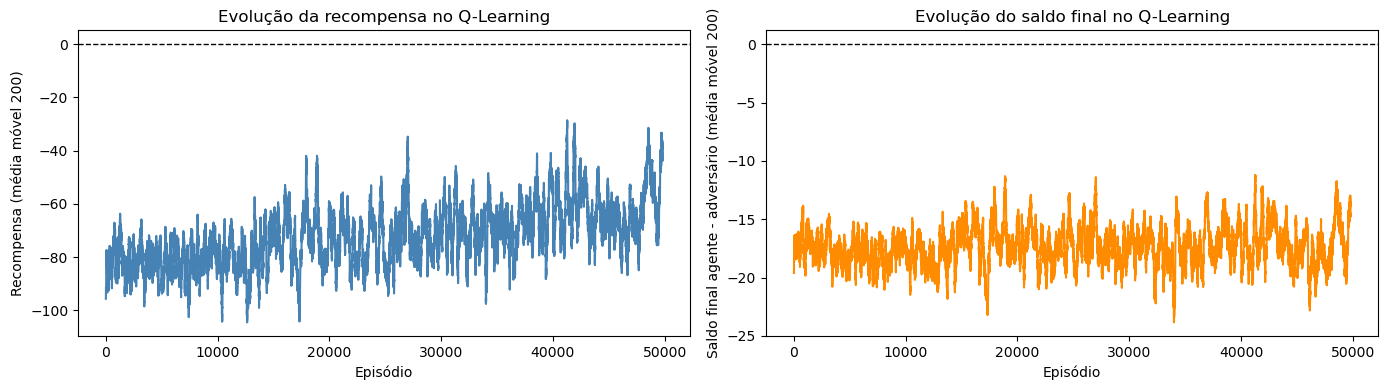

In [20]:
window = 200
rewards_smoothed = np.convolve(rewards_log, np.ones(window) / window, mode="valid")
score_diff_smoothed = np.convolve(final_score_diffs_log, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(rewards_smoothed, color="steelblue")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Episódio")
axes[0].set_ylabel("Recompensa (média móvel 200)")
axes[0].set_title("Evolução da recompensa no Q-Learning")

axes[1].plot(score_diff_smoothed, color="darkorange")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Episódio")
axes[1].set_ylabel("Saldo final agente - adversário (média móvel 200)")
axes[1].set_title("Evolução do saldo final no Q-Learning")

plt.tight_layout()
plt.savefig("flip7_treinamento.png", dpi=150)
plt.show()


## 9. Conclusões

### O agente aprendeu algo útil?

Sim. O Q-Learning aprendeu uma política competitiva para jogar uma rodada de Flip-7 contra um adversário especial que nunca estoura. 

Nos gráficos de resultados, ele aparece com a melhor combinação entre recompensa média, taxa de vitória e saldo final médio. Mesmo quando ainda perde muitas rodadas, o agente treinado reduz a desvantagem média em relação às políticas de referência.

Esse resultado fica mais claro quando olhamos os gráficos em conjunto. 

O gráfico de **Recompensa Média** mostra o retorno agregado da política que é a maior contra todos os seus pares. 

O gráfico de **Distribuição do Resultado Final** mostra que o Q-Learning tende a vencer mais. 

Já o gráfico de **Média do DELTA Final nas Derrotas** mostra a severidade das derrotas: quanto menos negativo o DELTA médio nas derrotas, menor a distância para o adversário quando o agente perde. Com os parâmetros utilizados, a política obtida no Q-Learning aceita assumir riscos e perder em cenários semelhantes ao da política agressiva considerando somente o Delta Final. Nesse sentido, ou os parâmetros podem ser ajustados para buscar uma melhoria ou pode-se considerar que perder por aproximadamente por 30 pontos é o melhor cenário.

A recompensa combina o delta da diferença de pontuação a cada passo com uma recompensa terminal baseada no resultado e na margem: `K_REWARD + K_BONUS_TO_REVENGE * tanh(DELTA / LIMIT_TO_REVENGE)`. Com isso, o agente não aprende apenas a vencer; ele também recebe sinal para diminuir derrotas grandes e valorizar vitórias com margem.

Essa tentativa de cálculo de recompnsa serve para incentivar o agente ( mesmo que não esteja 100% coberto nesse modelo ) a busca de diminuir a vantagem em uma possível derrota para recuperar nas próximas rodadas.

### Quando o agente tende a puxar carta?

Pelo mapa de estados, o agente tende a puxar quando o saldo está em `destruido` ou `perdendo`, principalmente quando o risco é `baixo` ou `medio`. Essa decisão é coerente: se o agente já está atrás, parar tende a preservar uma derrota. Puxar aumenta o risco de estouro, mas também é a única forma de recuperar o DELTA.

O agente também tende a puxar em alguns estados `empatado` ou `ganhando` quando ainda possui poucas cartas e o risco permanece administrável. Nesses casos, a política aprendida indica que buscar mais pontos ainda compensa, especialmente antes de o risco de repetição se tornar alto.

### Quando o agente tende a parar?

O agente tende a parar quando já está `ganhando` ou `amassando` e o risco de repetição sobe para `alto` ou `critico`. Essa decisão aparece no mapa como células vermelhas em regiões de vantagem, principalmente quando o agente já tem uma quantidade intermediária ou alta de cartas.

Esse comportamento é importante porque o agente, diferente do adversário especial usado no treino, perde a pontuação da rodada se comprar uma carta repetida. Portanto, quando a vantagem já existe, a melhor decisão muitas vezes é proteger o saldo em vez de tentar ampliar a margem.

### Qual política foi melhor e por quê?

O Q-Learning foi a melhor política porque ajustou o nível de risco ao estado da partida. A política conservadora evita estouros, mas para cedo demais e por isso vence pouco. A política agressiva busca recuperação com mais frequência, mas aceita muitos estouros. O Q-Learning fica entre esses extremos: ele puxa quando a situação exige recuperação e para quando o mapa de estados indica que a vantagem já deve ser preservada.

O gráfico de severidade das derrotas complementa essa leitura. Mesmo quando o Q-Learning perde, a média do DELTA final nas derrotas tende a ser menos negativa que nas políticas mais fracas. Isso mostra que a política aprendida não melhora apenas a taxa de vitória; ela também reduz o tamanho médio das derrotas.

### Limitações/Simplificações do modelo

- O jogo foi modelado como uma rodada isolada contra um adversário especial que sempre tomará a melhor decisão. No jogo original, temos diversas rodadas sem reset de baralho.
  
- A recompensa usa o delta da diferença de pontuação durante a rodada e uma recompensa terminal com resultado e margem, incluindo o bonus de Flip-7 na pontuação final de quem conseguiu o feito. As recompensas são parametrizadas, o que pode afetar o objetivo do agente dependendo do peso que se passa para cada um dos parâmetros.


- A diferença de pontuação, a quantidade de cartas e o risco de repetição são discretizados para manter a tabela Q pequena. Isso simplifica o modelo mas talvez reduza a efetividade do agente enxergar ou descobrir ações melhores se considerar um cenário ou um estado mais detalhado.

  
- O Q-Learning tabular depende das categorias escolhidas; mudanças nos limites podem mudar a política aprendida e consequentemente o comportamento do agente.

  
- O adversário foi modelado com a regra especial descrita: ele continua puxando até tentar repetir, devolve a carta ao monte e para sem perder pontos. O que torna a quantidade de derrotas elevada para o agente já que ele não tem a mesma vantagem da melhor jogada determinística.


## 10. Jogo Interativo contra o Q-Learning

Execute a célula abaixo para iniciar uma rodada jogável de Flip-7. Você controla o jogador humano e decide entre **Puxar carta** ou **Parar**. A cada ação sua, o agente responde com exatamente uma decisão da política Q-Learning. Se você parar, estourar ou fizer Flip-7, o agente continua automaticamente até encerrar a própria participação.


In [21]:
try:
    import ipywidgets as widgets
    from IPython.display import HTML, clear_output, display
except ImportError:
    widgets = None


class QLearningFlip7Duel:
    def __init__(self):
        self.output = None
        self.draw_button = None
        self.stop_button = None
        self.new_game_button = None
        self.reset()

    def reset(self):
        self.deck = build_deck()
        self.human = PlayerState()
        self.q_agent = PlayerState()
        self.done = False
        self.log = []
        self._deal_initial_cards()

    def _deal_initial_cards(self):
        self.human.cards.append(draw_random_card(self.deck))
        self.q_agent.cards.append(draw_random_card(self.deck))
        self.log.append("Nova rodada iniciada.")
        self.log.append(f"Voce recebeu a carta {self.human.cards[-1]}.")
        self.log.append("O agente Q-Learning recebeu sua carta inicial.")
        self.log.append("Sua vez: escolha puxar carta ou parar.")

    def _policy_state_for_q_agent(self):
        class PolicyView:
            pass

        view = PolicyView()
        view.agent = self.q_agent
        view.opponent = self.human
        view.deck = self.deck
        return get_state(view)

    def _draw_for(self, player: PlayerState, label: str) -> str:
        if not self.deck:
            player.stopped = True
            return f"{label} nao comprou porque o baralho acabou."

        card = draw_random_card(self.deck)
        if card in player.cards:
            player.busted = True
            player.stopped = True
            return f"{label} puxou {card}, repetiu carta e estourou."

        player.cards.append(card)
        if player_has_flip7(player):
            player.flip7_bonus = True
            player.stopped = True
            return f"{label} puxou {card} e fez Flip-7."

        return f"{label} puxou {card}."

    def human_draw(self, _=None):
        if self.done or self.human.stopped:
            return

        self.log.append("Sua acao: puxar carta.")
        self.log.append(self._draw_for(self.human, "Voce"))
        self._advance_after_human_action()
        self.render()

    def human_stop(self, _=None):
        if self.done or self.human.stopped:
            return

        self.human.stopped = True
        self.log.append("Sua acao: parar.")
        self._advance_after_human_action()
        self.render()

    def new_game(self, _=None):
        self.reset()
        self.render()

    def _advance_after_human_action(self):
        self._stop_active_players_if_deck_empty()

        if self._both_players_stopped():
            self._finish_game()
            return

        if self.human.stopped:
            self._run_q_agent_until_stop()
            self._finish_game()
            return

        self._q_agent_respond_once()
        self._stop_active_players_if_deck_empty()

        if self._both_players_stopped():
            self._finish_game()
        elif self.q_agent.stopped:
            self.log.append("O agente ja encerrou. Voce pode continuar jogando.")
        else:
            self.log.append("Sua vez novamente.")

    def _q_agent_respond_once(self):
        if self.done or self.q_agent.stopped:
            return

        if not self.deck:
            self.q_agent.stopped = True
            self.log.append("O agente Q-Learning parou porque o baralho acabou.")
            return

        state = self._policy_state_for_q_agent()
        action = q_policy(state)

        if action == Action.STOP:
            self.q_agent.stopped = True
            self.log.append("Resposta do agente: parar.")
            return

        self.log.append("Resposta do agente: puxar carta.")
        self.log.append(self._draw_for(self.q_agent, "O agente Q-Learning"))

    def _run_q_agent_until_stop(self):
        if self.q_agent.stopped:
            return

        self.log.append("Voce encerrou sua participacao. O agente continua ate parar.")
        while not self.q_agent.stopped and self.deck:
            self._q_agent_respond_once()

        self._stop_active_players_if_deck_empty()

    def _stop_active_players_if_deck_empty(self):
        if self.deck:
            return

        if not self.human.stopped:
            self.human.stopped = True
            self.log.append("Voce parou porque o baralho acabou.")
        if not self.q_agent.stopped:
            self.q_agent.stopped = True
            self.log.append("O agente Q-Learning parou porque o baralho acabou.")

    def _both_players_stopped(self) -> bool:
        return self.human.stopped and self.q_agent.stopped

    def _finish_game(self):
        if self.done:
            return

        self.done = True
        human_score = self.human.final_score
        q_score = self.q_agent.final_score
        delta_human = human_score - q_score

        self.log.append("Rodada finalizada.")
        if delta_human > 0:
            self.log.append(f"Voce venceu por {delta_human} pontos.")
        elif delta_human < 0:
            self.log.append(f"O agente venceu por {-delta_human} pontos.")
        else:
            self.log.append("A rodada terminou empatada.")

    def _player_html(self, label: str, player: PlayerState) -> str:
        status = []
        if player.busted:
            status.append("estourou")
        if player.flip7_bonus:
            status.append("Flip-7")
        if player.stopped and not player.busted:
            status.append("parou")
        status_text = ", ".join(status) if status else "em jogo"
        cards = ", ".join(map(str, player.cards))
        return f"""
        <div style='border:1px solid #bbb; padding:10px; margin:6px 0;'>
            <strong>{label}</strong><br>
            Cartas: {cards}<br>
            Pontuacao atual: {player.raw_score}<br>
            Pontuacao final: {player.final_score}<br>
            Estado: {status_text}
        </div>
        """

    def render(self):
        if self.output is None:
            return

        with self.output:
            clear_output(wait=True)
            display(HTML(
                self._player_html("Voce", self.human)
                + self._player_html("Agente Q-Learning", self.q_agent)
                + f"<p><strong>Cartas restantes no baralho:</strong> {len(self.deck)}</p>"
                + "<hr>"
                + "<br>".join(self.log[-14:])
            ))

        if self.draw_button is not None:
            self.draw_button.disabled = self.done or self.human.stopped
            self.stop_button.disabled = self.done or self.human.stopped

    def display(self):
        if widgets is None:
            display(HTML("<strong>ipywidgets nao esta instalado neste ambiente.</strong>"))
            return

        self.draw_button = widgets.Button(description="Puxar carta", button_style="success")
        self.stop_button = widgets.Button(description="Parar", button_style="warning")
        self.new_game_button = widgets.Button(description="Nova rodada", button_style="info")
        self.output = widgets.Output()

        self.draw_button.on_click(self.human_draw)
        self.stop_button.on_click(self.human_stop)
        self.new_game_button.on_click(self.new_game)

        display(widgets.VBox([
            widgets.HBox([self.draw_button, self.stop_button, self.new_game_button]),
            self.output,
        ]))
        self.render()


interactive_game = QLearningFlip7Duel()
interactive_game.display()
